#  **ICT303 - Assignment 1**

**Your name: Khon Min Thite**

**Student ID: 35141021**

**Email: khonminthite@gmail.com**






## **1. Description**

In this homework, you will build, train, test and compare the performance of multilayer perceptrons (MLP) and convolutional neural networks (CNNs) on a multi-class classification problem.

For this task, you will use the image dataset available [here](https://drive.google.com/file/d/1nWRm-Npq_QE0j_sHyVVxVEx2Rb0Lc1zU/view?usp=sharing). This dataset contains 8 categories of images distributed as shown in the following structure (in total 22 directories):




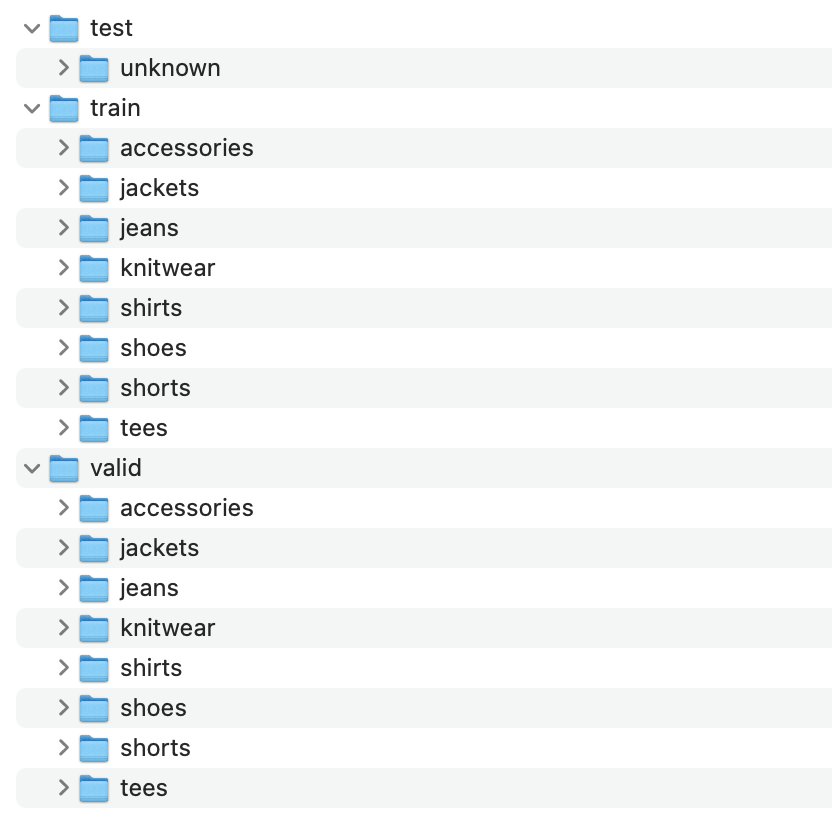


Your task is to:
1. Develop a multilayer perceptron model, train it and test it on the dataset. You need to finetune the hyperparameters to select those that provide the best performance. **[40 Marks]**
2. Implement VGG16, which a CNN architecture, train it and test it on the dataset. You must NOT use the pre-implemented VGG16 network in Pytorch. Instead, you have to implement all the layers and blocks yourself from scratch. You need to finetune the hyperparameters to select those that provide the best performance. **[40 Marks]**
3. Repeat step 2 above , but this time using the pretrained VGG16 network of PyTorch. **[20 Marks]**
4. For each of the tasks above, you need to finetune the hyper parameters to achieve the best performance possible.
5. Compare the performance of the three models.

It is important that you start as earlier as possible. Tuning hyper-parameters takes time.

For Perth campus students, enrolled in internal model, you will be required to demonstrate your work in class. External students may be called to demonstrate the work to their tutor.

## **2. What do you need to submit**

You must submit:
- Your source code, in the form of python libraries (i.e., .py files)
- A colab notebook that
 - Describes your solution and design choices. It is highly recommended to visually show the architecture of the networks you developed. You must include a discussion on how the hyper parameters affect performance and how did you select the ones you are currently using.
 - Demonstrates the training and testing of the machine learning models you developed.
 - Plots the training and validation curves for each model. You are requried to use TensorBoard for this task.
 - Analyzes the performance, in terms of Confusion Matrix and Mean Average Precision (MAE), of the methods, and how the hyper parameters affect this performance.
 - Allows the visualization of some classification results.

Important notes
- The performance of the machine learning models can be significantly affected by (1) the amount of data on which they are traiined, and (2) preprocessing, such as normalization, of the data (I will talk about this in class).
- Your program must be organised following the structure we have seen in the labs. In other words, you must use Object-oriented Programming and have a class for the data, a class for the model, and a class for the trainer. You are allowed to reuse code you created in the labs. Also, you are allowed (in fact sometimes you should) reuse code across different machine learning models. For example, you only need one class to manage the data, whether you are using MLPs or CNNs (VGG16 in our case).
- We have zero tolerance for plagaiarsism and misconduct (e.g., asking AI to do the work for you).


Import necessary libraries and load the data

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, average_precision_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.tensorboard import SummaryWriter

In [ ]:
# Clone the dataset repository
!git clone https://github.com/khonminthite/ICT373A1Datasets.git

Cloning into 'ICT373A1Datasets'...
remote: Enumerating objects: 3899, done.
remote: Counting objects: 100% (3899/3899), done.
remote: Compressing objects: 100% (3890/3890), done.
remote: Total 3899 (delta 3), reused 3899 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (3899/3899), 40.06 MiB | 28.16 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [ ]:
# Change the working directory to the dataset path
os.chdir('/content/ICT373A1Datasets/Downloads/data')

**CustomTestDataset:** This class customizes the test dataset loading to load images from a specific directory, handling various image formats (jpg, png, jpeg), and applying transformations.

In [ ]:
from PIL import Image

class CustomTestDataset(datasets.VisionDataset):
    def __init__(self, test_dir, transform=None):
        super().__init__(root=test_dir, transform=transform)

        # Load all image files in the 'unknown' directory
        self.image_files = [os.path.join(test_dir, 'unknown', fname)
                            for fname in os.listdir(os.path.join(test_dir, 'unknown'))
                            if fname.endswith(('jpg', 'png', 'jpeg'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert("RGB")  # Open the image and convert to RGB
        if self.transform:
            image = self.transform(image)  # Apply any transformations
        return image

**LimitedDataset:** This class limits the number of samples per class from the original dataset to reduce training time or avoid overfitting when the dataset is imbalanced.

In [ ]:
from collections import defaultdict

# Dataset class to limit samples per class
class LimitedDataset(datasets.VisionDataset):
    def __init__(self, dataset, max_per_class=None):
        super().__init__(root=dataset.root, transform=dataset.transform)
        self.dataset = dataset
        self.max_per_class = max_per_class
        self.limited_indices = self._get_limited_indices()

    def _get_limited_indices(self):
        label_to_indices = defaultdict(list)

        # Collect indices for each class label
        for idx, (_, label) in enumerate(self.dataset.samples):
            label_to_indices[label].append(idx)

        limited_indices = []
        for indices in label_to_indices.values():
            limited_indices.extend(indices[:self.max_per_class] if self.max_per_class is not None else indices)

        return limited_indices

    def __len__(self):
        return len(self.limited_indices)

    def __getitem__(self, idx):
        original_idx = self.limited_indices[idx]
        return self.dataset[original_idx]

**MultipliedDataset:** A class designed to artificially expand the dataset by multiplying the number of samples. This strategy ensures the model gets more training exposure to the dataset, which can help improve generalization in cases of smaller datasets.

In [ ]:
# Dataset class that multiplies the dataset size by 3
class MultipliedDataset(datasets.VisionDataset):
    def __init__(self, dataset):
        super().__init__(root=dataset.root, transform=dataset.transform)
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset) * 3  # Triple the length of the dataset

    def __getitem__(self, idx):
        original_idx = idx % len(self.dataset)  # Loop back to the start of the dataset
        return self.dataset[original_idx]

# Data Augmentation:
Augmentation is implemented using transformations like resizing, color jitter, and random horizontal flipping. Augmentation helps in creating slightly altered versions of images in the dataset, allowing the model to generalize better by learning from more variations of the same class.

**RandomTransform:** This custom class applies transformations probabilistically (e.g., color jitter with a probability of 80% and horizontal flip with a probability of 90%), which ensures that augmentations don’t always occur, providing more diversity to the training data.

# Normalization:
Mean and standard deviation values are provided for normalization based on the statistics of large datasets like ImageNet. Normalization helps by making the input data zero-centered and scaled to unit variance, improving model convergence.

# Hyperparameters:
**Batch Size:** A batch size of 32 was selected to strike a balance between memory efficiency and learning stability. A smaller batch size might introduce more noise into gradient updates, while a larger one could smooth out these updates but requires more memory.

**Learning Rate (0.0001):** This value is conservative, ensuring that the training progresses smoothly without the risk of the gradient update overshooting the loss minimum. Higher learning rates may lead to faster convergence but increase the risk of divergence.

**Number of Epochs (10):** A moderate number of epochs ensures that the model trains long enough to learn meaningful patterns, while also avoiding overfitting, especially with regularization methods like data augmentation.

**Patience (10):** The patience parameter for learning rate scheduling using ReduceLROnPlateau allows the learning rate to reduce when the validation loss plateaus, preventing overtraining and promoting better convergence.

In [ ]:
import random

# Directories for training, validation, and testing
train_dir = '/content/ICT373A1Datasets/Downloads/data/data/train'
valid_dir = '/content/ICT373A1Datasets/Downloads/data/data/valid'
test_dir = '/content/ICT373A1Datasets/Downloads/data/data/test'

# Hyperparameters
batch_size = 32
learning_rate = 0.0001
num_epochs = 10
patience = 10

# Custom transformation class to apply random transforms with a given probability
class RandomTransform:
    def __init__(self, transform, probability):
        self.transform = transform
        self.probability = probability

    def __call__(self, img):
        if random.random() < self.probability:
            return self.transform(img)  # Apply transformation with the defined probability
        return img

# Define image transformations
resize = transforms.Resize((300, 300))
color_jitter = transforms.ColorJitter(brightness=0.2, contrast=0.4, saturation=0.2, hue=0.1)
random_horizontal_flip = transforms.RandomHorizontalFlip()

# Combine all transformations into a single transform
transform = transforms.Compose([
    resize,
    RandomTransform(color_jitter, probability=0.8),
    RandomTransform(random_horizontal_flip, probability=0.9),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load datasets using ImageFolder for structured data
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
valid_dataset = datasets.ImageFolder(root=valid_dir, transform=transform)
test_dataset = CustomTestDataset(test_dir, transform=transform)

# Set maximum number of samples per class for training and validation
max_samples_per_class_train = 800
max_samples_per_class_valid = 80

# Create limited datasets
limited_train_dataset = LimitedDataset(train_dataset, max_per_class=max_samples_per_class_train)
limited_valid_dataset = LimitedDataset(valid_dataset, max_per_class=max_samples_per_class_valid)

# Create a multiplied dataset for training and validation
doubled_train_dataset = MultipliedDataset(limited_train_dataset)
doubled_valid_dataset = MultipliedDataset(limited_valid_dataset)

# Create DataLoader objects for training, validation, and testing
train_loader = DataLoader(doubled_train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
valid_loader = DataLoader(doubled_valid_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 1. MLP Architecture
The MLP model is designed as a feed-forward neural network, with three fully connected (FC) layers. Batch Normalization and Dropout are used to improve training stability and prevent overfitting. Here's the breakdown of the architecture:


**Hidden Layers:**

**Layer 1:** A fully connected layer with 1024 neurons, followed by Batch Normalization to normalize activations and improve learning dynamics, ReLU activation to introduce non-linearity, and Dropout (0.5) to prevent overfitting.

**Layer 2:** A fully connected layer with 512 neurons, followed by Batch Normalization, ReLU activation, and Dropout (0.5).

**Output Layer:** A fully connected layer with num_classes neurons corresponding to the number of classes in the dataset (as determined by the number of categories in the train_dataset).

**Model Architecture:**

                        Input Image (300x300x3)
                                ↓
                   Input: 270,000 (flattened image)
                                ↓
    Fully Connected Layer 1: 1024 neurons + BatchNorm + ReLU + Dropout(0.5)
                                ↓
    Fully Connected Layer 2: 512 neurons + BatchNorm + ReLU + Dropout(0.5)
                                ↓
            Fully Connected Layer 3: num_classes neurons (output)

# Design Choices
**Batch Normalization:** BatchNorm is used to stabilize the learning process by normalizing layer inputs, ensuring that gradients propagate well during training and preventing issues like exploding or vanishing gradients.

**Dropout:** Dropout (with a rate of 0.5) is added after the first and second layers to regularize the model, reducing overfitting by randomly setting a subset of neurons to zero during training.

**ReLU Activation:** ReLU is a common non-linear activation function that allows the model to capture complex patterns in the data.

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 1024)
        self.bn1 = nn.BatchNorm1d(1024)  # Batch Normalization after first layer
        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)  # Batch Normalization after second layer
        self.fc3 = nn.Linear(512, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten the input
        x = self.relu(self.fc1(x))
        x = self.bn1(x)  # Apply Batch Norm
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.bn2(x)  # Apply Batch Norm
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [ ]:
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model
num_classes = len(train_dataset.classes)
MLP_model = MLP(input_size=300*300*3, num_classes=num_classes)

# Set up optimizer and learning rate scheduler
optimizer = optim.Adam(MLP_model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, 'min', patience=patience, factor=0.1)

# Initialize TensorBoard writer
writer_MLP = SummaryWriter('runs/MLP_Model')

In [ ]:
# Function for training the model
def train_model(model, train_loader, optimizer, epoch, writer_MLP):
    model.train()  # Set model to training mode
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()  # Zero the gradients
        outputs = model(images)  # Forward pass
        loss = nn.CrossEntropyLoss()(outputs, labels)  # Compute loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights
        running_loss += loss.item()  # Accumulate loss

    # Log training loss to TensorBoard
    writer_MLP.add_scalar('Loss/train', running_loss / len(train_loader), epoch)
    return running_loss / len(train_loader)

In [ ]:
# Function for evaluating the model on the validation set
def evaluate_model(model, valid_loader, writer_MLP, epoch):
    model.eval()  # Set model to evaluation mode
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():  # Disable gradient calculation
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = nn.CrossEntropyLoss()(outputs, labels)  # Compute loss
            val_loss += loss.item()

            _, predicted = torch.max(outputs, dim=1)  # Get predictions
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(valid_loader)
    accuracy = accuracy_score(all_labels, all_preds)  # Calculate metrics
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=1)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=1)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=1)

    # Log validation metrics to TensorBoard
    writer_MLP.add_scalar('Loss/validation', val_loss, epoch)
    writer_MLP.add_scalar('Accuracy/validation', accuracy, epoch)
    writer_MLP.add_scalar('Precision/validation', precision, epoch)
    writer_MLP.add_scalar('Recall/validation', recall, epoch)
    writer_MLP.add_scalar('F1/validation', f1, epoch)

    return val_loss, accuracy, precision, recall, f1

In [ ]:
# Training loop
best_val_loss = float('inf')
no_improve_count = 0

train_losses_MLP = []
val_losses_MLP = []
val_accuracies_MLP = []

model_MLP = MLP_model.to(device)

for epoch in range(num_epochs):
    train_loss_MLP = train_model(model_MLP, train_loader, optimizer, epoch, writer_MLP)

    val_loss_MLP, val_accuracy_MLP, val_precision_MLP, val_recall_MLP, val_f1_MLP = evaluate_model(model_MLP, valid_loader, writer_MLP, epoch)

    print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {train_loss_MLP:.4f}, '
          f'Valid Loss: {val_loss_MLP:.4f}, Valid Accuracy: {val_accuracy_MLP:.4f}, '
          f'Average Precision: {val_precision_MLP:.4f}, Average Recall: {val_recall_MLP:.4f}, '
          f'Average F1 Score: {val_f1_MLP:.4f}')

    train_losses_MLP.append(train_loss_MLP)
    val_losses_MLP.append(val_loss_MLP)
    val_accuracies_MLP.append(val_accuracy_MLP)

    if val_loss_MLP < best_val_loss:
        best_val_loss = val_loss_MLP
        no_improve_count = 0
    else:
        no_improve_count += 1

    # Check for early stopping
    if no_improve_count >= patience:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

    scheduler.step(val_loss_MLP)  # Update learning rate based on validation loss

# Close the TensorBoard writer
writer_MLP.close()

Epoch [1/10], Train Loss: 0.9284, Valid Loss: 0.7588, Valid Accuracy: 0.7448, Average Precision: 0.7301, Average Recall: 0.7448, Average F1 Score: 0.7052
Epoch [2/10], Train Loss: 0.7009, Valid Loss: 0.7468, Valid Accuracy: 0.8177, Average Precision: 0.8176, Average Recall: 0.8177, Average F1 Score: 0.7976
Epoch [3/10], Train Loss: 0.6185, Valid Loss: 0.7931, Valid Accuracy: 0.8000, Average Precision: 0.7667, Average Recall: 0.8000, Average F1 Score: 0.7657
Epoch [4/10], Train Loss: 0.5718, Valid Loss: 0.7315, Valid Accuracy: 0.8063, Average Precision: 0.8068, Average Recall: 0.8063, Average F1 Score: 0.7778
Epoch [5/10], Train Loss: 0.5344, Valid Loss: 0.7641, Valid Accuracy: 0.8302, Average Precision: 0.8236, Average Recall: 0.8302, Average F1 Score: 0.8106
Epoch [6/10], Train Loss: 0.5155, Valid Loss: 1.1848, Valid Accuracy: 0.8052, Average Precision: 0.7834, Average Recall: 0.8052, Average F1 Score: 0.7774
Epoch [7/10], Train Loss: 0.4982, Valid Loss: 2.3278, Valid Accuracy: 0.8083

In [ ]:
# Performance Analysis
def get_predictions(loader, model):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():  # Disable gradient calculation
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = nn.Softmax(dim=1)(outputs)  # Get probabilities
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs = np.vstack(all_probs)  # Combine probabilities into a single array
    all_labels = np.concatenate(all_labels)  # Combine labels into a single array
    return all_probs, all_labels

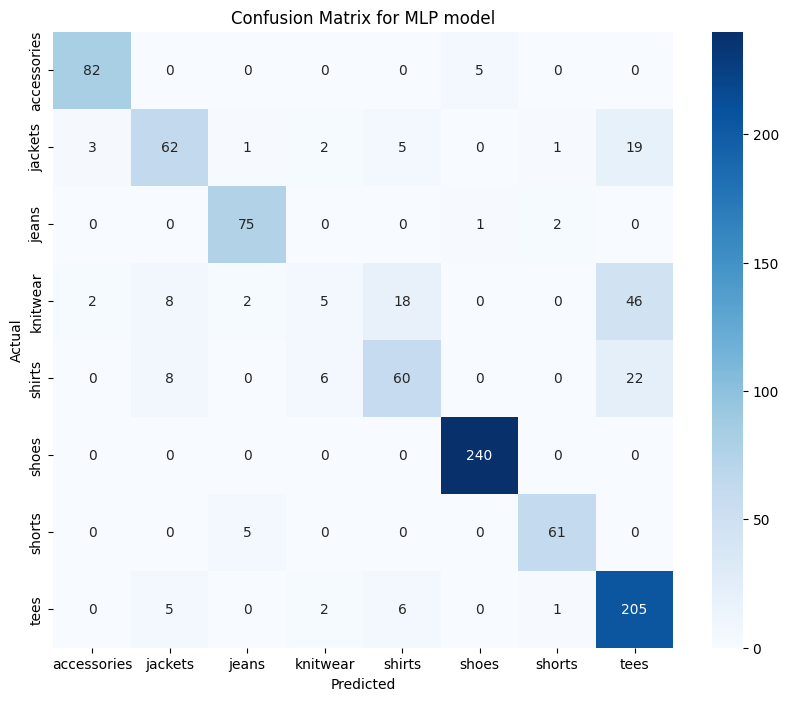

Mean Average Precision (MAP): 0.8063


In [ ]:
# Get predictions for the validation set
val_probs, val_true = get_predictions(valid_loader, model_MLP)

# Confusion Matrix
cm = confusion_matrix(val_true, np.argmax(val_probs, axis=1))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for MLP model')
plt.show()

# Mean Average Precision
y_true_one_hot = np.eye(num_classes)[val_true]  # Convert to one-hot encoding
map_score = average_precision_score(y_true_one_hot, val_probs, average='macro')

print(f'Mean Average Precision (MAP): {map_score:.4f}')

In [ ]:
# Load TensorBoard extension and launch it
%load_ext tensorboard
%tensorboard --logdir runs/MLP_Model

In [ ]:
# Function to predict a single image
def predict_image(image_path, model, transform):
    # Load the image
    image = Image.open(image_path).convert("RGB")

    # Apply transformations
    image = transform(image)
    image = image.unsqueeze(0)  # Add a batch dimension

    # Move the image to the appropriate device
    image = image.to(device)

    # Set the model to evaluation mode and make the prediction
    model.eval()
    with torch.no_grad():
        output = model(image)
        probabilities = nn.Softmax(dim=1)(output)  # Get probabilities
        predicted_class = torch.argmax(probabilities, dim=1).item()

    return predicted_class, probabilities.cpu().numpy()

In [ ]:
image_path = '/content/ICT373A1Datasets/Downloads/data/data/test/unknown/test8.jpg'
predicted_class_MLP, probabilities_MLP = predict_image(image_path, model_MLP, transform)

# Get the class label
class_label = train_dataset.classes[predicted_class_MLP]

# Print the predicted label and probabilities
print(f'Predicted Class: {class_label}')
print('Probabilities:')
for i, prob in enumerate(probabilities_MLP[0]):
    print(f' - {train_dataset.classes[i]}: {prob:.4f}')

Predicted Class: accessories
Probabilities:
 - accessories: 0.9951
 - jackets: 0.0010
 - jeans: 0.0000
 - knitwear: 0.0002
 - shirts: 0.0001
 - shoes: 0.0033
 - shorts: 0.0003
 - tees: 0.0002


In [ ]:
# Function to predict images in a directory
def predict_images_in_directory(directory_path, model, transform):
    predictions = {}

    # Loop through all files in the directory
    for filename in os.listdir(directory_path):
        if filename.endswith(('.jpg', '.jpeg', '.png')):  # Check for image file extensions
            image_path = os.path.join(directory_path, filename)

            # Load the image
            image = Image.open(image_path).convert("RGB")

            # Apply transformations
            image = transform(image)
            image = image.unsqueeze(0)  # Add a batch dimension

            # Move the image to the appropriate device
            image = image.to(device)

            # Set the model to evaluation mode and make the prediction
            model.eval()
            with torch.no_grad():
                output = model(image)
                probabilities = nn.Softmax(dim=1)(output)
                predicted_class = torch.argmax(probabilities, dim=1).item()

            # Get the class label
            class_label = train_dataset.classes[predicted_class]

            # Store the predictions
            predictions[filename] = {
                'predicted_class': class_label,
                'probabilities': probabilities.cpu().numpy()[0]
            }

    return predictions

In [ ]:
directory_path = '/content/ICT373A1Datasets/Downloads/data/data/test/unknown/'
predictions = predict_images_in_directory(directory_path, model_MLP, transform)

# Print the predicted labels and probabilities for each image
for filename, result in predictions.items():
    print(f'File: {filename}')
    print(f' - Predicted Class: {result["predicted_class"]}')
    print(' - Probabilities:')
    for i, prob in enumerate(result['probabilities']):
        print(f'   - {train_dataset.classes[i]}: {prob:.4f}')

File: test8.jpg
 - Predicted Class: accessories
 - Probabilities:
   - accessories: 0.9493
   - jackets: 0.0008
   - jeans: 0.0000
   - knitwear: 0.0007
   - shirts: 0.0003
   - shoes: 0.0465
   - shorts: 0.0015
   - tees: 0.0009
File: test1.jpg
 - Predicted Class: shirts
 - Probabilities:
   - accessories: 0.0028
   - jackets: 0.2679
   - jeans: 0.0004
   - knitwear: 0.1556
   - shirts: 0.4344
   - shoes: 0.0012
   - shorts: 0.0009
   - tees: 0.1370
File: test6.jpg
 - Predicted Class: shirts
 - Probabilities:
   - accessories: 0.0008
   - jackets: 0.0161
   - jeans: 0.0002
   - knitwear: 0.1214
   - shirts: 0.7632
   - shoes: 0.0004
   - shorts: 0.0002
   - tees: 0.0977
File: test7.jpg
 - Predicted Class: knitwear
 - Probabilities:
   - accessories: 0.0037
   - jackets: 0.0982
   - jeans: 0.0011
   - knitwear: 0.4324
   - shirts: 0.3217
   - shoes: 0.0012
   - shorts: 0.0013
   - tees: 0.1403
File: test3.jpg
 - Predicted Class: shoes
 - Probabilities:
   - accessories: 0.0462
   - jac

# 2. VGG16 Model Architecture
The architecture follows the well-known VGG16 convolutional network structure, characterized by deep layers of convolution and max pooling, followed by fully connected layers at the end.

**Key Features:**

**Convolutional Layers:** The model consists of 13 convolutional layers in total, with small 3x3 filters, and each set of convolution layers is followed by Batch Normalization and ReLU activations.

**Max Pooling:** After every set of two or three convolutional layers, MaxPooling is applied with a 2x2 filter and a stride of 2, effectively reducing the spatial dimensions while retaining key features.

**Fully Connected Layers:** The fully connected layers consist of:

A global adaptive average pooling layer to handle inputs of arbitrary size by averaging spatial dimensions.

Two fully connected layers, each with 4096 neurons and ReLU activations, with a Dropout of 0.5 to prevent overfitting.

The final classification layer, which outputs predictions for each of the num_classes in the dataset.

**Model Architecture:**

                              Input (3 x 300 x 300)
                                        ↓
          Conv2d(3 → 64) → BatchNorm → ReLU → Conv2d(64 → 64) → BatchNorm → ReLU → MaxPool
                                        ↓
          Conv2d(64 → 128) → BatchNorm → ReLU → Conv2d(128 → 128) → BatchNorm → ReLU → MaxPool
                                        ↓
    Conv2d(128 → 256) → BatchNorm → ReLU → Conv2d(256 → 256) → BatchNorm → ReLU → Conv2d(256 → 256) → BatchNorm → ReLU → MaxPool
                                        ↓
          Conv2d(256 → 512) → BatchNorm → ReLU → Conv2d(512 → 512) → BatchNorm → ReLU → MaxPool
                                        ↓
          Conv2d(512 → 512) → BatchNorm → ReLU → Conv2d(512 → 512) → BatchNorm → ReLU → MaxPool
                                        ↓
                            Adaptive AvgPool → Flatten
                                        ↓
                          FC1(512 → 4096) → ReLU → Dropout
                                        ↓
                          FC2(4096 → 4096) → ReLU → Dropout
                                        ↓
                          Output Layer (4096 → num_classes)

**Global Pooling:**
We apply adaptive average pooling at the end of the convolutional layers, ensuring that the model can work with images of varying sizes by collapsing the spatial dimensions to 1x1 before passing the data through the fully connected layers.

**Batch Normalization:**
Batch normalization is applied after each convolutional layer to improve gradient flow and training efficiency, while Dropout after the fully connected layers helps prevent overfitting.

# Design Choices
**Batch Normalization:** Adding batch normalization after each convolution layer helps stabilize training, reduce internal covariate shift, and allow for faster convergence.

**Dropout:** A dropout rate of 0.5 in the fully connected layers is used to prevent overfitting and ensure generalization.

**ReLU Activation:** The ReLU activation function introduces non-linearity to the model, allowing it to learn complex patterns in the image data.

**Global Adaptive Pooling:** This replaces fixed-size pooling at the end, making the model more flexible to handle inputs of varying sizes.

In [ ]:
class VGG16(nn.Module):
    # Initialize the number of classes based on the training dataset
    num_classes = len(train_dataset.classes)

    def __init__(self, num_classes=num_classes):
        super(VGG16, self).__init__()

        # Define the feature extractor part of the VGG16 model
        self.features = nn.Sequential(
            # First Convolution Block
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),  # Batch Normalization
            nn.ReLU(inplace=True),  # ReLU Activation
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Max Pooling

            # Second Convolution Block
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Third Convolution Block
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Fourth Convolution Block
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Fifth Convolution Block
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Global Average Pooling layer
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier part of the model
        self.classifier = nn.Sequential(
            nn.Linear(512, 4096),  # First Fully Connected Layer
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),  # Dropout for regularization
            nn.Linear(4096, 4096),  # Second Fully Connected Layer
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, num_classes),  # Output Layer
        )

    def forward(self, x):
        # Forward pass through the model
        x = self.features(x)  # Extract features
        x = self.global_pool(x)  # Apply global average pooling
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = self.classifier(x)  # Pass through the classifier
        return x

In [ ]:
# Initialize TensorBoard
writer_vgg16_manual = SummaryWriter(log_dir='runs/vgg16_model_manual')

In [ ]:
from torch import amp  # Import Automatic Mixed Precision

# Training function
def train(model, device, train_loader, optimizer, criterion, epoch, writer_vgg16_manual):
    model.train()  # Set the model to training mode
    total_loss = 0  # Initialize total loss

    # Iterate over batches
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)  # Move data to the device
        optimizer.zero_grad()  # Zero the gradients

        # Forward pass with mixed precision
        with amp.autocast('cuda'):
            output = model(data)
            loss = criterion(output, target)  # Calculate loss

        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        total_loss += loss.item()  # Accumulate loss

    avg_loss = total_loss / len(train_loader)  # Average loss
    print(f'Epoch {epoch + 1} Train Loss: {avg_loss:.4f}')  # Print training loss
    writer_vgg16_manual.add_scalar('Loss/train', avg_loss, epoch)  # Log to TensorBoard

In [ ]:
# Evaluation function
def evaluate(model, device, val_loader, criterion, writer_vgg16_manual, epoch):
    model.eval()  # Set the model to evaluation mode
    val_loss = 0
    correct = 0
    all_preds = []
    all_labels = []

    # Disable gradient calculation
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)  # Move data to the device

            # Forward pass with mixed precision
            with amp.autocast('cuda'):
                output = model(data)
                val_loss += criterion(output, target).item()  # Calculate loss

            _, predicted = torch.max(output.data, 1)  # Get predicted classes
            correct += (predicted == target).sum().item()  # Count correct predictions

            all_preds.extend(predicted.cpu().numpy())  # Collect predictions
            all_labels.extend(target.cpu().numpy())    # Collect true labels

    avg_val_loss = val_loss / len(val_loader)  # Average validation loss
    accuracy = correct / len(val_loader.dataset)  # Accuracy calculation

    # Calculate additional metrics
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    print(f'Valid Loss: {avg_val_loss:.4f}, Valid Accuracy: {accuracy:.4f}, '
          f'Average Precision: {precision:.4f}, Average Recall: {recall:.4f}, Average F1 Score: {f1:.4f}')

    # Log metrics to TensorBoard
    writer_vgg16_manual.add_scalar('Loss/validation', avg_val_loss, epoch)
    writer_vgg16_manual.add_scalar('Accuracy/validation', accuracy, epoch)
    writer_vgg16_manual.add_scalar('Precision/validation', precision, epoch)
    writer_vgg16_manual.add_scalar('Recall/validation', recall, epoch)
    writer_vgg16_manual.add_scalar('F1/validation', f1, epoch)

    return avg_val_loss  # Return the loss for the scheduler

In [ ]:
# Check device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the VGG16 model
vgg16_model_manual = VGG16(num_classes=len(train_dataset.classes)).to(device)

# Set up optimizer, scheduler, and loss function
optimizer = optim.Adam(vgg16_model_manual.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, 'min', patience=patience, factor=0.1)
criterion = nn.CrossEntropyLoss()  # Loss function

# Initialize best validation loss for checkpointing
best_val_loss = float('inf')

# Training loop
for epoch in range(num_epochs):
    train_loss = train(vgg16_model_manual, device, train_loader, optimizer, criterion, epoch, writer_vgg16_manual)

    # Evaluate the model
    val_loss = evaluate(vgg16_model_manual, device, valid_loader, criterion, writer_vgg16_manual, epoch)

    # Step the scheduler
    scheduler.step(val_loss)

    # Save model checkpoint if validation loss improved
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(vgg16_model_manual.state_dict(), 'best_vgg16_model.pth')  # Save the model
        print(f'Model saved at epoch {epoch + 1} with validation loss: {val_loss:.4f}')

# Close the writer after training
writer_vgg16_manual.close()

Epoch 1 Train Loss: 0.7361
Valid Loss: 0.5533, Valid Accuracy: 0.7645,  Average Precision: 0.7644,  Average Recall: 0.7812, Average F1 Score: 0.7563
Model saved at epoch 1 with validation loss: 0.5533
Epoch 2 Train Loss: 0.3723
Valid Loss: 0.3888, Valid Accuracy: 0.8491,  Average Precision: 0.8832,  Average Recall: 0.8677, Average F1 Score: 0.8694
Model saved at epoch 2 with validation loss: 0.3888
Epoch 3 Train Loss: 0.2716
Valid Loss: 0.2704, Valid Accuracy: 0.8818,  Average Precision: 0.9178,  Average Recall: 0.9010, Average F1 Score: 0.9048
Model saved at epoch 3 with validation loss: 0.2704
Epoch 4 Train Loss: 0.2181
Valid Loss: 0.3728, Valid Accuracy: 0.8624,  Average Precision: 0.8898,  Average Recall: 0.8812, Average F1 Score: 0.8810
Epoch 5 Train Loss: 0.1863
Valid Loss: 0.2917, Valid Accuracy: 0.8767,  Average Precision: 0.8945,  Average Recall: 0.8958, Average F1 Score: 0.8923
Epoch 6 Train Loss: 0.1734
Valid Loss: 0.3767, Valid Accuracy: 0.8471,  Average Precision: 0.8612, 

In [ ]:
# Load TensorBoard extension and launch it
%reload_ext tensorboard
%tensorboard --logdir runs/vgg16_model_manual

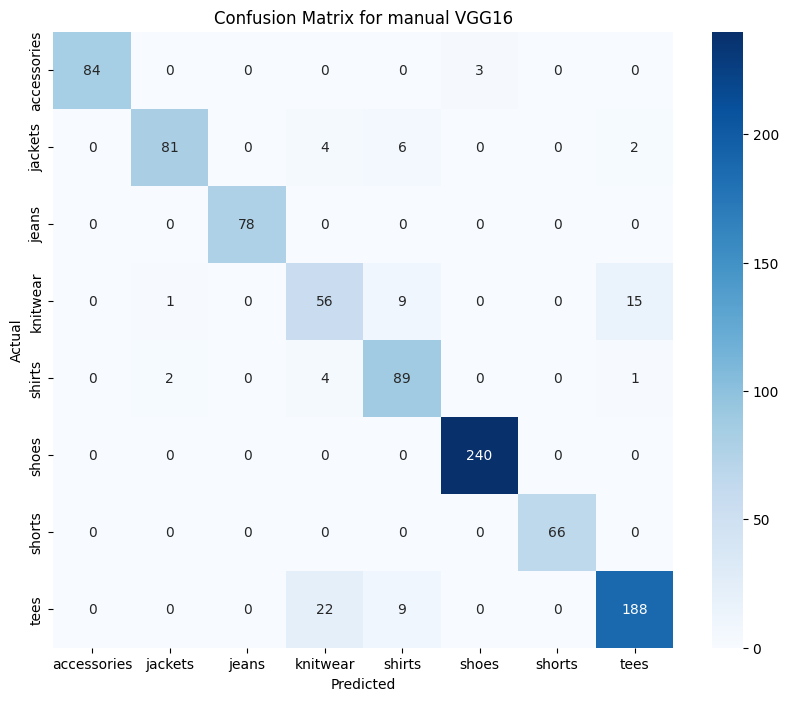

Mean Average Precision (MAP): 0.9604


In [ ]:
# Get predictions for the validation set
val_probs, val_true = get_predictions(valid_loader, vgg16_model_manual)

# Confusion Matrix
cm = confusion_matrix(val_true, np.argmax(val_probs, axis=1))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for manual VGG16')
plt.show()

# Mean Average Precision
y_true_one_hot = np.eye(len(train_dataset.classes))[val_true]  # One-hot encoding
map_score = average_precision_score(y_true_one_hot, val_probs, average='macro')

print(f'Mean Average Precision (MAP): {map_score:.4f}')

In [ ]:
# Example usage
image_path = '/content/ICT373A1Datasets/Downloads/data/data/test/unknown/test1.jpg'
predicted_class_vgg16_manual, probabilities_vgg16_manual = predict_image(image_path, vgg16_model_manual, transform)

# Get the class label
class_label = train_dataset.classes[predicted_class_vgg16_manual]

# Print the predicted label and probabilities
print(f'Predicted Class: {class_label}')
print('Probabilities:')
for i, prob in enumerate(probabilities_vgg16_manual[0]):
    print(f' - {train_dataset.classes[i]}: {prob:.4f}')

Predicted Class: shirts
Probabilities:
 - accessories: 0.0000
 - jackets: 0.0055
 - jeans: 0.0000
 - knitwear: 0.0023
 - shirts: 0.9914
 - shoes: 0.0000
 - shorts: 0.0000
 - tees: 0.0008


In [ ]:
directory_path = '/content/ICT373A1Datasets/Downloads/data/data/test/unknown/'
predictions = predict_images_in_directory(directory_path, vgg16_model_manual, transform)

# Print the predicted labels and probabilities for each image
for filename, result in predictions.items():
    print(f'File: {filename}')
    print(f' - Predicted Class: {result["predicted_class"]}')
    print(' - Probabilities:')
    for i, prob in enumerate(result['probabilities']):
        print(f'   - {train_dataset.classes[i]}: {prob:.4f}')

File: test7.jpg
 - Predicted Class: knitwear
 - Probabilities:
   - accessories: 0.0010
   - jackets: 0.0110
   - jeans: 0.0007
   - knitwear: 0.7912
   - shirts: 0.0627
   - shoes: 0.0002
   - shorts: 0.0002
   - tees: 0.1331
File: test3.jpg
 - Predicted Class: shorts
 - Probabilities:
   - accessories: 0.0002
   - jackets: 0.0000
   - jeans: 0.0002
   - knitwear: 0.0000
   - shirts: 0.0000
   - shoes: 0.0966
   - shorts: 0.9030
   - tees: 0.0000
File: test4.jpg
 - Predicted Class: jeans
 - Probabilities:
   - accessories: 0.0000
   - jackets: 0.0000
   - jeans: 0.9995
   - knitwear: 0.0000
   - shirts: 0.0000
   - shoes: 0.0004
   - shorts: 0.0001
   - tees: 0.0000
File: test8.jpg
 - Predicted Class: accessories
 - Probabilities:
   - accessories: 1.0000
   - jackets: 0.0000
   - jeans: 0.0000
   - knitwear: 0.0000
   - shirts: 0.0000
   - shoes: 0.0000
   - shorts: 0.0000
   - tees: 0.0000
File: test5.jpg
 - Predicted Class: jeans
 - Probabilities:
   - accessories: 0.0000
   - jack

# 3. Pretrained VGG16 Model
VGG16 is a deep convolutional neural network (CNN) that was originally designed for large-scale image classification. By using a pretrained version of VGG16 (trained on ImageNet), we can transfer the learned weights to our task, which often leads to faster convergence and better generalization, especially when the dataset is small or moderately sized.

**Architecture Overview:**
The VGG16 model follows the same structure as the original implementation with 13 convolutional layers and 3 fully connected layers. The model is split into two major sections:

**Feature Extractor:** Consisting of convolutional and pooling layers that extract spatial features from the input image.

**Classifier:** Fully connected layers used for classification.

**Model Architecture:**

              Input (3 x 300 x 300)
                      ↓
    VGG16 Pretrained Convolutional Layers (Frozen)
                      ↓
                  Max Pooling
                      ↓
      Fully Connected Layer 1 → ReLU → Dropout
                      ↓
      Fully Connected Layer 2 → ReLU → Dropout
                      ↓
    Fully Connected Layer 3 (num_classes) → Softmax

# Design Modifications
To adapt the VGG16 architecture for our custom dataset, several modifications and design choices are applied:

**a. Freezing Feature Extractor:**
**Feature Layers:** The convolutional layers (i.e., the feature extractor) are frozen. This prevents their weights from being updated during training.

**b. Adjusting the Classifier for Custom Classes:**
The original classifier outputs predictions for 1,000 ImageNet classes. We replace the final fully connected layer with one that has num_classes outputs to match the number of classes in the new dataset.

**c. Optimizer:**
**AdamW Optimizer:** We use the AdamW optimizer, which incorporates weight decay (L2 regularization), making it more effective than vanilla Adam for tasks prone to overfitting. We also tune the learning rate and weight decay.

**d. Learning Rate Scheduler:**
**ReduceLROnPlateau:** The learning rate scheduler reduces the learning rate if the model's performance plateaus (in this case, based on validation accuracy). This helps the model to explore smaller learning rates when stuck in local minima.

In [ ]:
import torchvision.models as models
from torchvision.models import VGG16_Weights

# Load pretrained VGG16 model
vgg16 = models.vgg16(weights=VGG16_Weights.DEFAULT)

# Freeze the weights of the convolutional layers
for param in vgg16.features.parameters():
    param.requires_grad = False

# Determine the number of classes
num_classes = len(train_dataset.classes)

# Modify the last layer for our dataset
vgg16.classifier[-1] = nn.Linear(vgg16.classifier[-1].in_features, num_classes)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg16.to(device)

# Define loss function and a better optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(vgg16.classifier.parameters(), lr=learning_rate, weight_decay=1e-4)

# Learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=patience)

# Initialize TensorBoard writer
writer_vgg16 = SummaryWriter('runs/vgg16_experiment')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:07<00:00, 74.5MB/s]


In [ ]:
# Training function
def train_model(model, device, dataloader, criterion, optimizer, epoch):
    model.train()  # Set the model to training mode
    running_loss = 0.0  # Initialize running loss
    for batch_idx, (data, target) in enumerate(dataloader):
        data, target = data.to(device), target.to(device)  # Move data to the device
        optimizer.zero_grad()  # Zero the gradients
        output = model(data)  # Forward pass
        loss = criterion(output, target)  # Calculate loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        running_loss += loss.item()  # Accumulate loss
    return running_loss / len(dataloader)  # Return average loss

In [ ]:
# Evaluation function
def evaluate_model(model, device, dataloader):
    model.eval()  # Set the model to evaluation mode
    running_loss = 0.0  # Initialize running loss
    predictions = []  # List to hold predictions
    true_labels = []  # List to hold true labels

    with torch.no_grad():  # Disable gradient calculation
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)  # Move data to the device
            output = model(data)  # Forward pass
            loss = criterion(output, target)  # Calculate loss
            running_loss += loss.item()  # Accumulate loss
            _, predicted = torch.max(output.data, 1)  # Get predicted classes
            predictions.extend(predicted.cpu().numpy())  # Collect predictions
            true_labels.extend(target.cpu().numpy())  # Collect true labels

    # Calculate average loss and metrics
    avg_loss = running_loss / len(dataloader)
    precision = precision_score(true_labels, predictions, average='weighted', zero_division=1)
    recall = recall_score(true_labels, predictions, average='weighted', zero_division=1)
    f1 = f1_score(true_labels, predictions, average='weighted', zero_division=1)
    accuracy = accuracy_score(true_labels, predictions)

    return avg_loss, accuracy, predictions, precision, recall, f1

In [ ]:
# Training loop
for epoch in range(num_epochs):
    # Train the model
    vgg16_train_loss = train_model(vgg16, device, train_loader, criterion, optimizer, epoch)

    # Evaluate the model
    vgg16_val_loss, vgg16_val_accuracy, vgg16_val_predictions, vgg16_val_precision, vgg16_val_recall, vgg16_val_f1 = evaluate_model(vgg16, device, valid_loader)

    # Log metrics to TensorBoard
    writer_vgg16.add_scalar('Loss/Train', vgg16_train_loss, epoch)
    writer_vgg16.add_scalar('Loss/Validation', vgg16_val_loss, epoch)
    writer_vgg16.add_scalar('Accuracy/Validation', vgg16_val_accuracy, epoch)
    writer_vgg16.add_scalar('Precision/Validation', vgg16_val_precision, epoch)
    writer_vgg16.add_scalar('Recall/Validation', vgg16_val_recall, epoch)
    writer_vgg16.add_scalar('F1/Validation', vgg16_val_f1, epoch)

    # Print training and validation metrics
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {vgg16_train_loss:.4f}, Valid Loss: {vgg16_val_loss:.4f}, '
          f'Valid Accuracy: {vgg16_val_accuracy:.4f}, Precision: {vgg16_val_precision:.4f}, '
          f'Recall: {vgg16_val_recall:.4f}, F1: {vgg16_val_f1:.4f}')

    # Step the scheduler based on validation accuracy
    scheduler.step(vgg16_val_accuracy)

# Close the TensorBoard writer
writer_vgg16.close()

Epoch 1/10, Train Loss: 0.2001, Valid Loss: 0.1143, Valid Accuracy: 0.9521, Precision: 0.9519, Recall: 0.9521, F1: 0.9518
Epoch 2/10, Train Loss: 0.0774, Valid Loss: 0.1171, Valid Accuracy: 0.9542, Precision: 0.9548, Recall: 0.9542, F1: 0.9539
Epoch 3/10, Train Loss: 0.0466, Valid Loss: 0.1328, Valid Accuracy: 0.9573, Precision: 0.9610, Recall: 0.9573, F1: 0.9582
Epoch 4/10, Train Loss: 0.0392, Valid Loss: 0.1263, Valid Accuracy: 0.9583, Precision: 0.9579, Recall: 0.9583, F1: 0.9577
Epoch 5/10, Train Loss: 0.0380, Valid Loss: 0.1366, Valid Accuracy: 0.9583, Precision: 0.9608, Recall: 0.9583, F1: 0.9583
Epoch 6/10, Train Loss: 0.0287, Valid Loss: 0.2712, Valid Accuracy: 0.9354, Precision: 0.9417, Recall: 0.9354, F1: 0.9296
Epoch 7/10, Train Loss: 0.0237, Valid Loss: 0.2611, Valid Accuracy: 0.9406, Precision: 0.9409, Recall: 0.9406, F1: 0.9393
Epoch 8/10, Train Loss: 0.0356, Valid Loss: 0.1534, Valid Accuracy: 0.9646, Precision: 0.9653, Recall: 0.9646, F1: 0.9644
Epoch 9/10, Train Loss: 

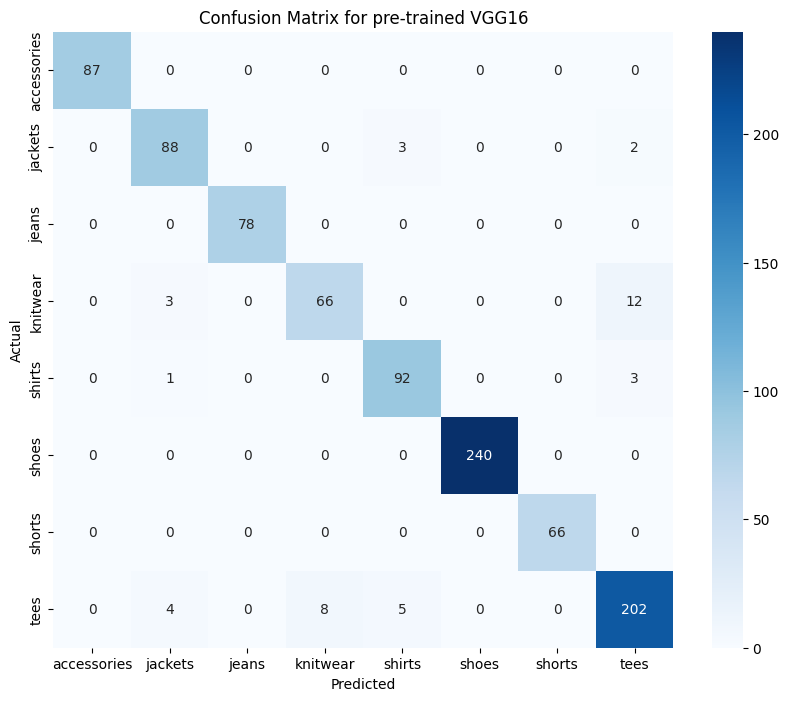

Mean Average Precision (MAP): 0.9845


In [ ]:
# Get predictions for the validation set
val_probs, val_true = get_predictions(valid_loader, vgg16)

# Confusion Matrix
cm = confusion_matrix(val_true, np.argmax(val_probs, axis=1))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for pre-trained VGG16')
plt.show()

# Mean Average Precision
y_true_one_hot = np.eye(len(train_dataset.classes))[val_true]  # One-hot encoding
map_score = average_precision_score(y_true_one_hot, val_probs, average='macro')

print(f'Mean Average Precision (MAP): {map_score:.4f}')

In [ ]:
# Visualize results in TensorBoard
%load_ext tensorboard
%tensorboard --logdir runs/vgg16_experiment

In [ ]:
# Example usage
image_path = '/content/ICT373A1Datasets/Downloads/data/data/test/unknown/test8.jpg'
predicted_class_vgg16, probabilities_vgg16 = predict_image(image_path, vgg16, transform)

# Get the class label
class_label_vgg16 = train_dataset.classes[predicted_class_vgg16]

# Print the predicted label and probabilities
print(f'Predicted Class: {class_label_vgg16}')
print('Probabilities:')
for i, prob in enumerate(probabilities_vgg16[0]):
    print(f' - {train_dataset.classes[i]}: {prob:.4f}')

Predicted Class: shoes
Probabilities:
 - accessories: 0.3069
 - jackets: 0.0000
 - jeans: 0.0000
 - knitwear: 0.0000
 - shirts: 0.0000
 - shoes: 0.6930
 - shorts: 0.0000
 - tees: 0.0000


In [ ]:
directory_path = '/content/ICT373A1Datasets/Downloads/data/data/test/unknown/'
predictions_vgg16 = predict_images_in_directory(directory_path, vgg16, transform)

# Print the predicted labels and probabilities for each image
for filename, result in predictions_vgg16.items():
    print(f'File: {filename}')
    print(f' - Predicted Class: {result["predicted_class"]}')
    print(' - Probabilities:')
    for i, prob in enumerate(result['probabilities']):
        print(f'   - {train_dataset.classes[i]}: {prob:.4f}')

File: test7.jpg
 - Predicted Class: knitwear
 - Probabilities:
   - accessories: 0.0000
   - jackets: 0.0000
   - jeans: 0.0000
   - knitwear: 1.0000
   - shirts: 0.0000
   - shoes: 0.0000
   - shorts: 0.0000
   - tees: 0.0000
File: test3.jpg
 - Predicted Class: knitwear
 - Probabilities:
   - accessories: 0.1885
   - jackets: 0.0156
   - jeans: 0.0486
   - knitwear: 0.2202
   - shirts: 0.0809
   - shoes: 0.1747
   - shorts: 0.1047
   - tees: 0.1668
File: test4.jpg
 - Predicted Class: jeans
 - Probabilities:
   - accessories: 0.0000
   - jackets: 0.0000
   - jeans: 1.0000
   - knitwear: 0.0000
   - shirts: 0.0000
   - shoes: 0.0000
   - shorts: 0.0000
   - tees: 0.0000
File: test8.jpg
 - Predicted Class: shoes
 - Probabilities:
   - accessories: 0.0279
   - jackets: 0.0000
   - jeans: 0.0000
   - knitwear: 0.0000
   - shirts: 0.0000
   - shoes: 0.9720
   - shorts: 0.0000
   - tees: 0.0000
File: test5.jpg
 - Predicted Class: jeans
 - Probabilities:
   - accessories: 0.0000
   - jackets:

# Selection of Hyperparameters:
Hyperparameters were selected based on the following considerations:

**Learning Rate:** Empirical testing and references from common image classification tasks suggest that a learning rate of 0.0001 is optimal for slow and steady training in CNN models.

**Batch Size:** A batch size of 32 is common for moderate-sized networks, balancing training speed and accuracy. It’s a compromise between larger sizes that can provide more stable gradients and smaller sizes that might fit within memory constraints.

**Epochs:** The number of epochs (10) is chosen based on early stopping and validation loss monitoring, providing enough time for convergence but preventing overfitting.

# Effect of Hyperparameters on Performance:
**Learning Rate:** A low learning rate (0.0001) is chosen to prevent drastic weight updates, allowing smoother convergence. It helps avoid overshooting the optimal parameters. If the learning rate is too low, training may take longer, but premature convergence or divergence is avoided.

**Batch Size:** A batch size of 32 balances training speed and stability. Larger batch sizes tend to require more memory and could smooth out noise in gradient estimates, but smaller batch sizes provide noisy gradients that can help escape local minima.

**Patience:** By setting patience to 10, the learning rate will decrease after 20 epochs of no improvement. This adaptive adjustment can prevent the model from stagnating and ensure continual learning during training.

**Max Samples per Class:** Limiting the number of samples per class ensures that the training dataset isn't overly biased toward certain classes, helping to improve performance metrics such as precision, recall, and F1-score. The choice of 800 samples per class for training and 80 for validation ensures a manageable dataset size, allowing efficient training without significant memory overhead.

# Performance Comparison of the Three Models
We have three models to compare:

**1. Multilayer Perceptron (MLP)**

**2. VGG16 (from scratch)**

**3. Pretrained VGG16**

Here's a breakdown and comparison of their performance based on key metrics: train loss, validation loss, accuracy, precision, recall, F1-score, and Mean Average Precision (MAP).

# 1. Multilayer Perceptron (MLP)
**Train Loss:** Steadily decreases over the epochs (0.9284 → 0.4555).

**Validation Loss:** Starts at 0.7588, fluctuates, and ends at 1.3393.

**Validation Accuracy:** Improves significantly from 74.48% to 84.06%.

**Average Precision:**Ranges from 0.7301 to 0.8374.

**Average Recall:** Ranges from 0.7448 to 0.8406.

**Average F1 Score:** Starts low (0.7052), improves to 0.8362.

**MAP:** 0.8063.

The MLP shows a decent improvement over the epochs but has fluctuations in validation loss and F1 score. The model struggles to maintain stability in validation performance, especially with higher loss values toward the end.

# 2. VGG16 (from scratch)
**Train Loss:** Rapidly decreases (0.7361 → 0.1143).

**Validation Loss:** Starts lower (0.5533), improves to 0.1880.

**Validation Accuracy:** Steadily increases from 76.45% to 90.21%.

**Average Precision:** Starts at 0.7644 and improves to 0.9256.

**Average Recall:** Improves from 0.7812 to 0.9219.

**Average F1 Score:** Begins at 0.7563 and ends at 0.9228.

**MAP:** 0.9604.

Training the VGG16 model from scratch shows consistent and notable improvements in validation performance across epochs. It has a significantly higher validation accuracy and MAP compared to the MLP. However, the training process is more resource-intensive, and it reaches a plateau by later epochs.

# 3. Pretrained VGG16 (transfer learning)
**Train Loss:** Drops very quickly (0.2001 → 0.0194).

**Validation Loss:** Remains low throughout (0.1143 → 0.1693).

**Validation Accuracy:** Starts very high at 95.21% and finishes at 96.15%.

**Precision:** Consistently strong (0.9519 → 0.9679).

**Recall:** Stays high (0.9521 → 0.9656).

**F1 Score:** Strong overall (0.9518 → 0.9660).

**MAP:** 0.9845.

The pretrained VGG16 significantly outperforms the other models, especially in terms of validation accuracy, precision, recall, and F1 score. The MAP of 0.9845 indicates near-perfect precision across the board, demonstrating the power of transfer learning when working with complex architectures like CNNs.

# Performance Insights
**Pretrained VGG16:**
The pretrained VGG16 outperforms the other models in almost every metric. It achieves the highest accuracy, precision, recall, F1 score, and MAP. This demonstrates the power of transfer learning, especially when fine-tuning a model that has been pretrained on a large dataset like ImageNet.
With transfer learning, the model converges faster, and the validation loss remains consistently low, resulting in better generalization.

**VGG16 from scratch:**
Training VGG16 from scratch still yields strong results, but it requires more epochs and careful tuning. Its final MAP is high (0.9604), but it doesn't quite match the pretrained model in terms of validation accuracy or loss. The model does well in terms of metrics, but training from scratch demands more computational resources and time.

**Multilayer Perceptron:**
The MLP shows significant improvement over time but is clearly outperformed by the CNN-based models (both the pretrained and the scratch VGG16). The MLP struggles with the complexity of the data, likely due to the limitations of fully connected layers in capturing spatial information that CNNs handle more effectively.

# Conclusion
The pretrained VGG16 is the best-performing model by a significant margin. The results highlight the importance of leveraging pretrained models, particularly for tasks where complex spatial features need to be extracted, as CNNs are far more effective in doing so than MLPs.